# 熵 Entropy：公式說明與 Python 運算範例

這份 Notebook 根據教材內容整理，示範如何用 Python 計算：

1. 單一事件資訊量
2. 熵 Entropy
3. 二元分布的熵
4. 條件熵 Conditional Entropy
5. 互資訊 Mutual Information

主要使用 `numpy`、`pandas` 與 `matplotlib`。


## 1. 熵的基本概念

熵用來衡量一個隨機變數的**平均不確定性**。

直覺上：

- 結果越難預測，熵越高。
- 結果越容易預測，熵越低。
- 熵不是單一事件的稀有性，而是整個機率分布的平均不確定性。

離散隨機變數 $X$ 的熵定義為：

$$
H(X)=-\sum_{i=1}^{n}p(x_i)\log_2 p(x_i)
$$

其中：

| 符號 | 意義 |
|---|---|
| $X$ | 離散隨機變數 |
| $x_i$ | 第 $i$ 個可能結果 |
| $p(x_i)$ | 結果 $x_i$ 的機率 |
| $\log_2$ | 以 2 為底的對數 |
| $H(X)$ | 熵，單位為 bit |


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. 單一事件資訊量

單一事件資訊量定義為：

$$
I(x)=-\log_2 p(x)
$$

這表示事件發生時的「驚訝程度」。

- 機率越小，資訊量越大。
- 機率越大，資訊量越小。
- 必然事件 $p=1$ 的資訊量為 0。


In [2]:
def information_content(p):
    """Calculate information content I(x) = -log2(p).

    Parameters
    ----------
    p : float or array-like
        Event probability or probabilities.

    Returns
    -------
    float or np.ndarray
        Information content in bits.
    """
    p = np.asarray(p, dtype=float)
    return -np.log2(p)

### 範例：不同事件的單一資訊量

| 事件 | 機率 |
|---|---:|
| 擲硬幣得到正面 | 1/2 |
| 擲骰子得到 6 | 1/6 |
| 抽中一張特定撲克牌 | 1/52 |
| 百萬分之一機率事件 | 1e-6 |


In [ ]:
events = pd.DataFrame(
    {
        "event": [
            "擲硬幣得到正面",
            "擲骰子得到 6",
            "抽中一張特定撲克牌",
            "百萬分之一機率事件",
        ],
        "probability": [1 / 2, 1 / 6, 1 / 52, 1e-6],
    }
)

events["information_bits"] = information_content(events["probability"])
events

,event,probability,information_bits
0,擲硬幣得到正面,0.500000,1.000000
1,擲骰子得到 6,0.166667,2.584963
2,抽中一張特定撲克牌,0.019231,5.700440
3,百萬分之一機率事件,0.000001,19.931569


## 3. 熵 Entropy 的 Python 函式

熵是單一事件資訊量的加權平均：

$$
H(X)=\sum_i p(x_i)I(x_i)
$$

也就是：

$$
H(X)=-\sum_i p(x_i)\log_2 p(x_i)
$$

下面寫成 Python 函式。


In [4]:
def entropy(probabilities):
    """Calculate entropy H(X) = -sum p(x) log2 p(x).

    Parameters
    ----------
    probabilities : array-like
        Probability distribution. Values should sum to 1.

    Returns
    -------
    float
        Entropy in bits.
    """
    p = np.asarray(probabilities, dtype=float)

    # 避免 p = 0 時 log2(0) 無定義。
    # 在熵的極限定義中，0 * log(0) 視為 0。
    p = p[p > 0]

    return -np.sum(p * np.log2(p))

## 4. 沙漠下雨範例

設隨機變數 $X$ 表示「今天有沒有下雨」。

沙漠一年只下一天雨：

$$
p(\text{下雨})=\frac{1}{365}
$$

$$
p(\text{不下雨})=\frac{364}{365}
$$

雖然「下雨」這個單一事件很意外，但整體而言，天氣其實非常好預測，因為幾乎每天都不下雨。


In [5]:
p_rain = 1 / 365
p_no_rain = 364 / 365

desert_distribution = [p_rain, p_no_rain]

rain_information = information_content(p_rain)
no_rain_information = information_content(p_no_rain)
desert_entropy = entropy(desert_distribution)

print(f"下雨的單一資訊量: {rain_information:.4f} bits")
print(f"不下雨的單一資訊量: {no_rain_information:.6f} bits")
print(f"沙漠天氣的整體熵: {desert_entropy:.4f} bits")

下雨的單一資訊量: 8.5118 bits
不下雨的單一資訊量: 0.003958 bits
沙漠天氣的整體熵: 0.0273 bits


### 解讀

下雨的單一資訊量很高，因為它非常罕見。

但是整體熵很低，因為大部分時間都不下雨，所以整個分布很容易預測。

這說明：

> 熵不是單一事件的稀有性，而是整個分布的平均不確定性。


## 5. 公平下雨與不下雨範例

如果下雨與不下雨機率各半：

$$
p(\text{下雨})=p(\text{不下雨})=\frac{1}{2}
$$

則熵為：

$$
H(X)=1 \text{ bit}
$$

這是二元變數的最大熵。


In [6]:
fair_weather_distribution = [0.5, 0.5]
fair_weather_entropy = entropy(fair_weather_distribution)

print(f"下雨與不下雨各半時的熵: {fair_weather_entropy:.4f} bit")

下雨與不下雨各半時的熵: 1.0000 bit


## 6. 比較不同二元分布的熵

對二元變數而言：

- 分布越平均，熵越高。
- 分布越集中，熵越低。
- $(0.5, 0.5)$ 時熵最大，為 1 bit。
- $(1, 0)$ 或 $(0, 1)$ 時熵最小，為 0 bit。


In [ ]:
binary_distributions = [
    (1.0, 0.0),
    (0.99, 0.01),
    (0.9, 0.1),
    (0.7, 0.3),
    (0.5, 0.5),
]

binary_df = pd.DataFrame(binary_distributions, columns=["p_event_1", "p_event_2"])
binary_df["entropy_bits"] = binary_df.apply(
    lambda row: entropy([row["p_event_1"], row["p_event_2"]]), axis=1
)
binary_df

,p_event_1,p_event_2,entropy_bits
0,1.00,0.00,-0.000000
1,0.99,0.01,0.080793
2,0.90,0.10,0.468996
3,0.70,0.30,0.881291
4,0.50,0.50,1.000000


## 7. 畫出二元熵曲線

令：

$$
p(X=1)=p
$$

$$
p(X=0)=1-p
$$

二元熵為：

$$
H(X)=-p\log_2 p-(1-p)\log_2(1-p)
$$


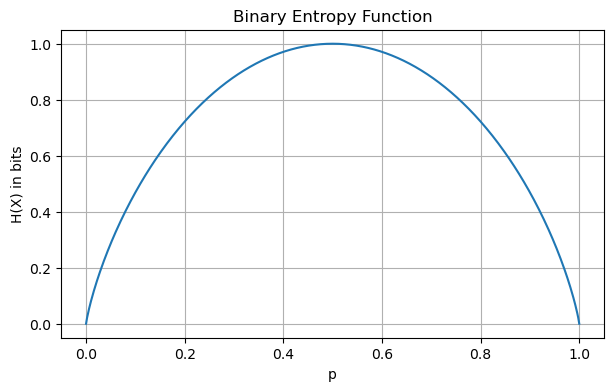

In [8]:
p_values = np.linspace(0, 1, 501)
entropy_values = [entropy([p, 1 - p]) for p in p_values]

plt.figure(figsize=(7, 4))
plt.plot(p_values, entropy_values)
plt.xlabel("p")
plt.ylabel("H(X) in bits")
plt.title("Binary Entropy Function")
plt.grid(True)
plt.show()

## 8. 條件熵 Conditional Entropy

條件熵表示已知條件變項 $T$ 後，目標變項 $X$ 還剩下多少不確定性。

公式為：

$$
H(X \mid T)=\sum_t p(t)H(X \mid T=t)
$$

教材中的例子：

- $p(T=\text{上半年})=0.5$
- $p(T=\text{下半年})=0.5$
- 上半年下雨機率為 0.9
- 下半年下雨機率為 0.1


In [ ]:
# T 的分布
p_T = {"上半年": 0.5, "下半年": 0.5}

# X | T 的條件分布
# 每個列表代表 [p(下雨), p(不下雨)]
conditional_X_given_T = {"上半年": [0.9, 0.1], "下半年": [0.1, 0.9]}

conditional_entropy = sum(p_T[t] * entropy(conditional_X_given_T[t]) for t in p_T)

conditional_entropy

np.float64(0.4689955935892812)

## 9. 不知道時間時的熵 $H(X)$

先求邊際分布：

$$
p(\text{下雨})=0.5\times0.9+0.5\times0.1=0.5
$$

$$
p(\text{不下雨})=0.5
$$

所以：

$$
H(X)=1 \text{ bit}
$$


In [10]:
p_rain_marginal = (
    p_T["上半年"] * conditional_X_given_T["上半年"][0]
    + p_T["下半年"] * conditional_X_given_T["下半年"][0]
)

p_no_rain_marginal = 1 - p_rain_marginal

H_X = entropy([p_rain_marginal, p_no_rain_marginal])

print(f"p(下雨) = {p_rain_marginal:.3f}")
print(f"p(不下雨) = {p_no_rain_marginal:.3f}")
print(f"H(X) = {H_X:.3f} bit")

p(下雨) = 0.500
p(不下雨) = 0.500
H(X) = 1.000 bit


## 10. 互資訊 Mutual Information

互資訊表示條件變項 $T$ 讓我們對 $X$ 的不確定性降低了多少。

公式為：

$$
I(X;T)=H(X)-H(X\mid T)
$$

在本例中：

$$
I(X;T)=1-0.469=0.531 \text{ bit}
$$


In [11]:
mutual_information = H_X - conditional_entropy

print(f"H(X) = {H_X:.3f} bit")
print(f"H(X | T) = {conditional_entropy:.3f} bit")
print(f"I(X; T) = {mutual_information:.3f} bit")

H(X) = 1.000 bit
H(X | T) = 0.469 bit
I(X; T) = 0.531 bit


## 11. 整理成表格

下面將 $H(X)$、$H(X|T)$、$I(X;T)$ 整理成表格。


In [ ]:
summary_df = pd.DataFrame(
    {
        "quantity": ["H(X)", "H(X | T)", "I(X; T)"],
        "value_bits": [H_X, conditional_entropy, mutual_information],
        "meaning": [
            "不知道時間時，天氣的平均不確定性",
            "知道時間後，天氣剩下的不確定性",
            "時間提供的資訊量，也就是不確定性下降的量",
        ],
    }
)

summary_df

,quantity,value_bits,meaning
0,H(X),1.000000,不知道時間時，天氣的平均不確定性
1,H(X | T),0.468996,知道時間後，天氣剩下的不確定性
2,I(X; T),0.531004,時間提供的資訊量，也就是不確定性下降的量


## 12. 小結

本 Notebook 展示了幾個重點：

1. 單一事件資訊量是 $I(x)=-\log_2 p(x)$。
2. 熵是整個分布的平均不確定性。
3. 罕見事件的資訊量可以很高，但整體熵不一定高。
4. 二元分布在 $(0.5,0.5)$ 時熵最大。
5. 條件熵表示知道條件後還剩多少不確定性。
6. 互資訊表示條件變項降低了多少不確定性。

一句話總結：

> 熵衡量不確定性；條件熵衡量已知條件後的剩餘不確定性；互資訊衡量不確定性被降低了多少。
